<a href="https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb)


Initializing Comparative Network Simulation...

Computing Topological Metrics...

--- Quantitative Topological Comparison ---
               Network Model  Nodes  Edges  Avg Degree  Clustering Coefficient  Avg Shortest Path Length
       Cosmic Web (BA Model)    150    441        5.88                  0.1348                    2.6910
Neural Connectome (WS Model)    150    450        6.00                  0.4657                    4.2457

Rendering Visualizations...


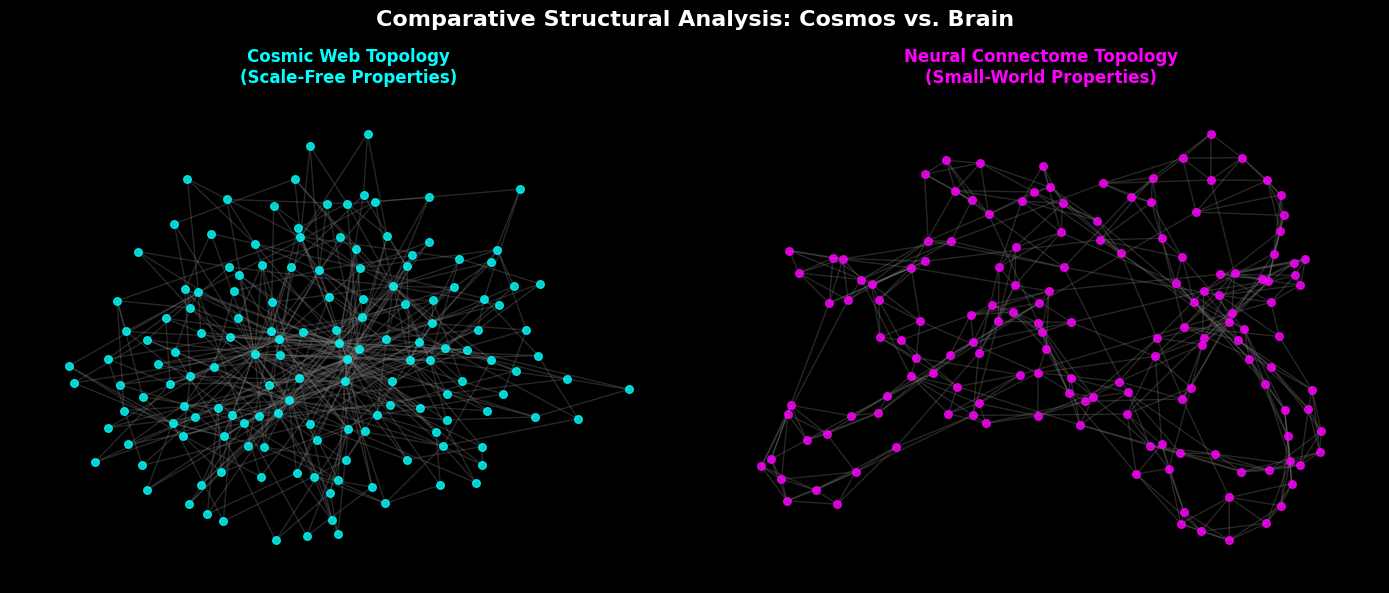

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def generate_comparative_networks():
    """
    Generates two distinct network models representing:
    1. Cosmic Web (Scale-free structural characteristics via Barabási-Albert model)
    2. Neural Connectome (Small-world structural characteristics via Watts-Strogatz model)
    """
    # Scale-free network for cosmic web simulations
    cosmic_net = nx.barabasi_albert_graph(n=150, m=3, seed=42)

    # Small-world network for human brain connectome simulations
    neural_net = nx.watts_strogatz_graph(n=150, k=6, p=0.08, seed=42)

    return cosmic_net, neural_net

def compute_topological_metrics(cosmic, neural):
    """
    Computes core graph theory metrics for comparative analysis.
    """
    networks = {'Cosmic Web (BA Model)': cosmic, 'Neural Connectome (WS Model)': neural}
    results = []

    for name, G in networks.items():
        # Core metrics
        clustering_coeff = nx.average_clustering(G)

        # Handle disconnected components safely for path length
        if nx.is_connected(G):
            path_length = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            subgraph = G.subgraph(largest_cc)
            path_length = nx.average_shortest_path_length(subgraph)

        avg_degree = np.mean([d for _, d in G.degree()])

        results.append({
            'Network Model': name,
            'Nodes': G.number_of_nodes(),
            'Edges': G.number_of_edges(),
            'Avg Degree': round(avg_degree, 4),
            'Clustering Coefficient': round(clustering_coeff, 4),
            'Avg Shortest Path Length': round(path_length, 4)
        })

    df = pd.DataFrame(results)
    return df

def plot_topologies(cosmic, neural):
    """
    Generates a publication-ready, dark-themed dual-panel visualization.
    """
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Layout positioning using spring layout for aesthetics
    pos_cosmic = nx.spring_layout(cosmic, seed=42)
    pos_neural = nx.spring_layout(neural, seed=42)

    # Cosmic Web Plot
    nx.draw_networkx_nodes(cosmic, pos_cosmic, ax=axes[0], node_size=30, node_color='cyan', alpha=0.8)
    nx.draw_networkx_edges(cosmic, pos_cosmic, ax=axes[0], edge_color='gray', alpha=0.3)
    axes[0].set_title("Cosmic Web Topology\n(Scale-Free Properties)", fontsize=12, fontweight='bold', color='cyan')
    axes[0].axis('off')

    # Neural Connectome Plot
    nx.draw_networkx_nodes(neural, pos_neural, ax=axes[1], node_size=30, node_color='magenta', alpha=0.8)
    nx.draw_networkx_edges(neural, pos_neural, ax=axes[1], edge_color='gray', alpha=0.3)
    axes[1].set_title("Neural Connectome Topology\n(Small-World Properties)", fontsize=12, fontweight='bold', color='magenta')
    axes[1].axis('off')

    plt.suptitle("Comparative Structural Analysis: Cosmos vs. Brain", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Execution Pipeline
if __name__ == "__main__":
    print("Initializing Comparative Network Simulation...")
    cosmic_graph, neural_graph = generate_comparative_networks()

    print("\nComputing Topological Metrics...")
    metrics_df = compute_topological_metrics(cosmic_graph, neural_graph)

    print("\n--- Quantitative Topological Comparison ---")
    print(metrics_df.to_string(index=False))

    print("\nRendering Visualizations...")
    plot_topologies(cosmic_graph, neural_graph)
